In [18]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)

RESULTS_SUMMARY = {
    "Logistic Regression": {
        "accuracy": 0.7919, "precision": 0.7394, "recall": 0.9606,
        "f1": 0.8356, "f1_macro": 0.7761, "f2": 0.9064, "f2_macro": 0.7689,
        "auc_pr": 0.8659, "tn": 21651, "fp": 15349, "fn": 1784, "tp": 43548,
        "train_acc": 0.8759, "train_f2_macro": 0.8747,
    },
    "Naive Bayes": {
        "accuracy": 0.5307, "precision": 0.5752, "recall": 0.5646,
        "f1": 0.5698, "f1_macro": 0.5267, "f2": 0.5667, "f2_macro": 0.5268,
        "auc_pr": 0.5503, "tn": 18097, "fp": 18903, "fn": 19738, "tp": 25594,
        "train_acc": 0.7996, "train_f2_macro": 0.7955,
    },
    "KNN": {
        "accuracy": 0.8572, "precision": 0.8111, "recall": 0.9656,
        "f1": 0.8816, "f1_macro": 0.8509, "f2": 0.9301, "f2_macro": 0.8451,
        "auc_pr": float("nan"), "tn": 26807, "fp": 10193, "fn": 1561, "tp": 43771,
        "train_acc": 0.9276, "train_f2_macro": 0.9274,
    },
    "SVM": {
        "accuracy": 0.3166, "precision": 0.3681, "recall": 0.3363,
        "f1": 0.3515, "f1_macro": 0.3147, "f2": 0.3422, "f2_macro": 0.3143,
        "auc_pr": float("nan"), "tn": 10824, "fp": 26176, "fn": 30087, "tp": 15245,
        "train_acc": 0.5519, "train_f2_macro": 0.5196,
    },
    "Decision Tree": {
        "accuracy": 0.8406, "precision": 0.7853, "recall": 0.9779,
        "f1": 0.8711, "f1_macro": 0.8312, "f2": 0.9322, "f2_macro": 0.8238,
        "auc_pr": 0.9802, "tn": 24880, "fp": 12120, "fn": 1001, "tp": 44331,
        "train_acc": 0.9163, "train_f2_macro": 0.9156,
    },
    "Random Forest": {
        "accuracy": 0.8443, "precision": 0.7872, "recall": 0.9831,
        "f1": 0.8743, "f1_macro": 0.8350, "f2": 0.9365, "f2_macro": 0.8273,
        "auc_pr": 0.9821, "tn": 24950, "fp": 12050, "fn": 766, "tp": 44566,
        "train_acc": 0.9619, "train_f2_macro": 0.9617,
    },
    "Gradient Boosting": {
        "accuracy": 0.8551, "precision": 0.8023, "recall": 0.9778,
        "f1": 0.8814, "f1_macro": 0.8476, "f2": 0.9368, "f2_macro": 0.8407,
        "auc_pr": 0.9843, "tn": 26075, "fp": 10925, "fn": 1005, "tp": 44327,
        "train_acc": 0.9326, "train_f2_macro": 0.9322,
    },
    "XGBoost": {
        "accuracy": 0.8494, "precision": 0.7939, "recall": 0.9811,
        "f1": 0.8776, "f1_macro": 0.8409, "f2": 0.9369, "f2_macro": 0.8335,
        "auc_pr": 0.9849, "tn": 25455, "fp": 11545, "fn": 857, "tp": 44475,
        "train_acc": 0.9287, "train_f2_macro": 0.9283,
    },
    "LightGBM": {
        "accuracy": 0.8489, "precision": 0.7930, "recall": 0.9818,
        "f1": 0.8774, "f1_macro": 0.8403, "f2": 0.9372, "f2_macro": 0.8328,
        "auc_pr": 0.9852, "tn": 25381, "fp": 11619, "fn": 823, "tp": 44509,
        "train_acc": 0.9271, "train_f2_macro": 0.9266,
    },
    "CatBoost": {
        "accuracy": 0.8424, "precision": 0.7851, "recall": 0.9826,
        "f1": 0.8728, "f1_macro": 0.8328, "f2": 0.9356, "f2_macro": 0.8251,
        "auc_pr": 0.9839, "tn": 24809, "fp": 12191, "fn": 787, "tp": 44545,
        "train_acc": 0.9201, "train_f2_macro": 0.9194,
    },
    "DNN": {
        "accuracy": 0.8202, "precision": 0.7573, "recall": 0.9912,
        "f1": 0.8586, "f1_macro": 0.8059, "f2": 0.9335, "f2_macro": 0.7971,
        "auc_pr": 0.9729, "tn": 22599, "fp": 14401, "fn": 401, "tp": 44931,
        "train_acc": 0.9059, "train_f2_macro": 0.9044,
    },
}

MODEL_NAMES = list(RESULTS_SUMMARY.keys())
df = pd.DataFrame(RESULTS_SUMMARY).T
print(f"Models loaded: {len(MODEL_NAMES)}")
print(df[["accuracy","precision","recall","f2_macro","auc_pr"]].to_string())

Models loaded: 11
                     accuracy  precision  recall  f2_macro  auc_pr
Logistic Regression    0.7919     0.7394  0.9606    0.7689  0.8659
Naive Bayes            0.5307     0.5752  0.5646    0.5268  0.5503
KNN                    0.8572     0.8111  0.9656    0.8451     NaN
SVM                    0.3166     0.3681  0.3363    0.3143     NaN
Decision Tree          0.8406     0.7853  0.9779    0.8238  0.9802
Random Forest          0.8443     0.7872  0.9831    0.8273  0.9821
Gradient Boosting      0.8551     0.8023  0.9778    0.8407  0.9843
XGBoost                0.8494     0.7939  0.9811    0.8335  0.9849
LightGBM               0.8489     0.7930  0.9818    0.8328  0.9852
CatBoost               0.8424     0.7851  0.9826    0.8251  0.9839
DNN                    0.8202     0.7573  0.9912    0.7971  0.9729


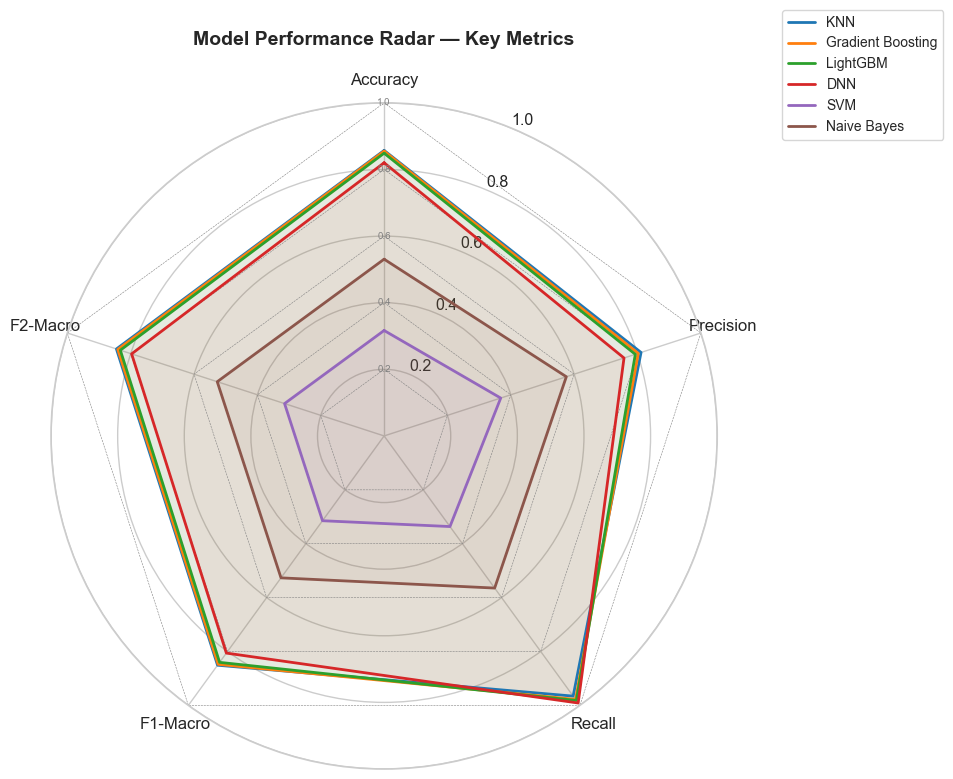

In [19]:

from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

RADAR_METRICS  = ["accuracy", "precision", "recall", "f1_macro", "f2_macro"]
RADAR_LABELS   = ["Accuracy", "Precision", "Recall", "F1-Macro", "F2-Macro"]
N              = len(RADAR_METRICS)
angles         = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles        += angles[:1]

HIGHLIGHT = ["KNN", "Gradient Boosting", "LightGBM", "DNN", "SVM", "Naive Bayes"]
palette    = sns.color_palette("tab10", n_colors=len(HIGHLIGHT))

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), RADAR_LABELS, fontsize=12)
ax.set_ylim(0, 1)
for r in [0.2, 0.4, 0.6, 0.8, 1.0]:
    ax.plot(angles, [r] * (N + 1), color="grey", linewidth=0.4, linestyle="--")
    ax.text(0, r, f"{r:.1f}", ha="center", va="center", fontsize=7, color="grey")

for idx, (name, color) in enumerate(zip(HIGHLIGHT, palette)):
    vals  = [RESULTS_SUMMARY[name][m] for m in RADAR_METRICS]
    vals  = [v if not np.isnan(v) else 0 for v in vals]
    vals += vals[:1]
    ax.plot(angles, vals, color=color, linewidth=2, label=name)
    ax.fill(angles, vals, color=color, alpha=0.06)

ax.set_title("Model Performance Radar — Key Metrics", fontsize=14,
             fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=10)
plt.tight_layout()
plt.savefig("results/analysis_radar_chart.png", dpi=150, bbox_inches="tight")
plt.show()

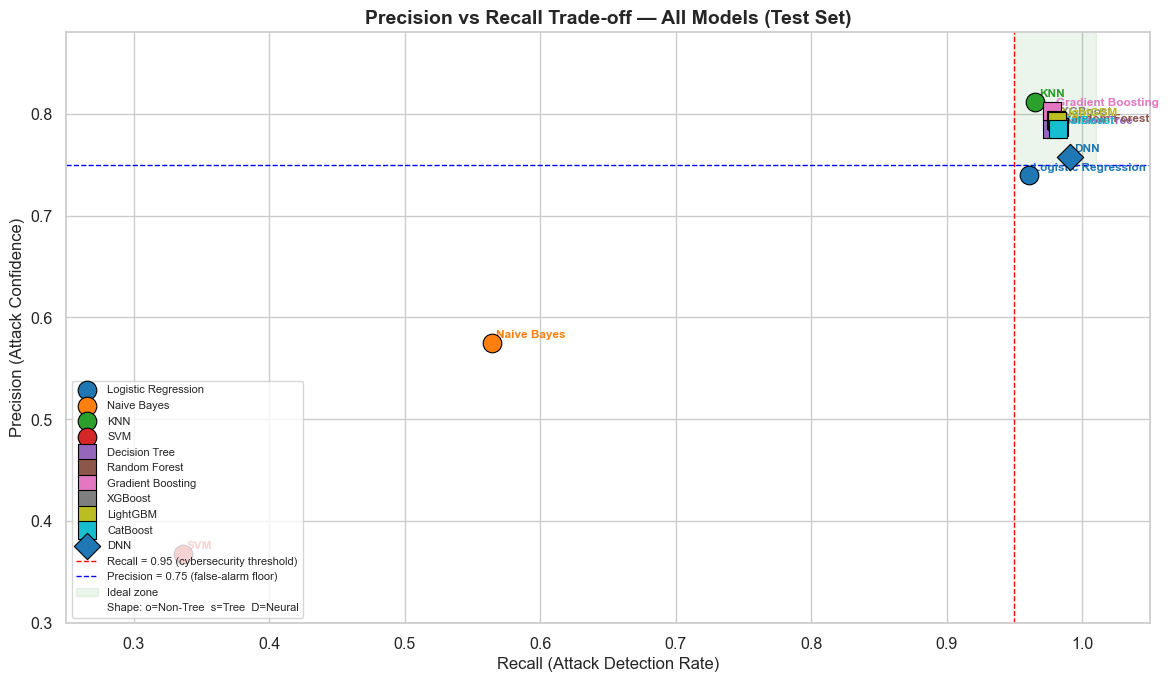

In [20]:

fig, ax = plt.subplots(figsize=(12, 7))

palette_full = sns.color_palette("tab10", n_colors=len(MODEL_NAMES))
MODEL_TYPE   = {
    "Logistic Regression": "Non-Tree",
    "Naive Bayes":         "Non-Tree",
    "KNN":                 "Non-Tree",
    "SVM":                 "Non-Tree",
    "Decision Tree":       "Tree",
    "Random Forest":       "Tree",
    "Gradient Boosting":   "Tree",
    "XGBoost":             "Tree",
    "LightGBM":            "Tree",
    "CatBoost":            "Tree",
    "DNN":                 "Neural",
}

marker_map = {"Non-Tree": "o", "Tree": "s", "Neural": "D"}

for idx, name in enumerate(MODEL_NAMES):
    prec = RESULTS_SUMMARY[name]["precision"]
    rec  = RESULTS_SUMMARY[name]["recall"]
    mtype= MODEL_TYPE[name]
    color= palette_full[idx]
    ax.scatter(rec, prec, s=180, color=color,
               marker=marker_map[mtype], edgecolors="black",
               linewidths=0.8, zorder=5, label=name)
    offset_x = 0.003
    offset_y = 0.005
    ax.annotate(name, (rec + offset_x, prec + offset_y),
                fontsize=8.5, color=color, fontweight="bold")

ax.axvline(0.95, color="red", linestyle="--", linewidth=1,
           label="Recall = 0.95 (cybersecurity threshold)")
ax.axhline(0.75, color="blue", linestyle="--", linewidth=1,
           label="Precision = 0.75 (false-alarm floor)")

ax.fill_between([0.95, 1.01], [0.75, 0.75], [1.01, 1.01],
                alpha=0.08, color="green", label="Ideal zone")

legend_handles = [
    mpatches.Patch(color="none", label="Shape: o=Non-Tree  s=Tree  D=Neural")
]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + legend_handles, labels + ["Shape: o=Non-Tree  s=Tree  D=Neural"],
          fontsize=8, loc="lower left")

ax.set_xlabel("Recall (Attack Detection Rate)", fontsize=12)
ax.set_ylabel("Precision (Attack Confidence)", fontsize=12)
ax.set_title("Precision vs Recall Trade-off — All Models (Test Set)", fontsize=14, fontweight="bold")
ax.set_xlim(0.25, 1.05)
ax.set_ylim(0.30, 0.88)
plt.tight_layout()
plt.savefig("results/analysis_precision_recall_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

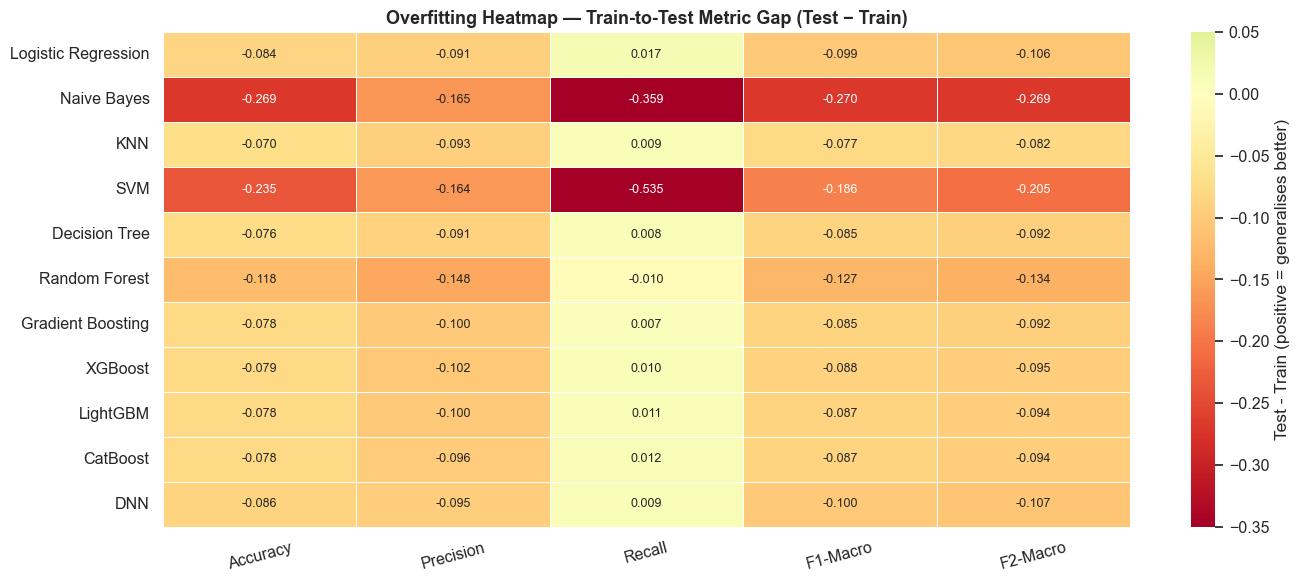

In [21]:

metrics_gap = ["accuracy", "precision", "recall", "f1_macro", "f2_macro"]
gap_df = pd.DataFrame(index=MODEL_NAMES, columns=metrics_gap, dtype=float)

TRAIN_VALS = {
    "Logistic Regression": {"accuracy": 0.8759, "precision": 0.8308, "recall": 0.9440, "f1_macro": 0.8753, "f2_macro": 0.8747},
    "Naive Bayes":         {"accuracy": 0.7996, "precision": 0.7402, "recall": 0.9234, "f1_macro": 0.7965, "f2_macro": 0.7955},
    "KNN":                 {"accuracy": 0.9276, "precision": 0.9043, "recall": 0.9563, "f1_macro": 0.9275, "f2_macro": 0.9274},
    "SVM":                 {"accuracy": 0.5519, "precision": 0.5317, "recall": 0.8715, "f1_macro": 0.5010, "f2_macro": 0.5196},
    "Decision Tree":       {"accuracy": 0.9163, "precision": 0.8759, "recall": 0.9700, "f1_macro": 0.9161, "f2_macro": 0.9156},
    "Random Forest":       {"accuracy": 0.9619, "precision": 0.9352, "recall": 0.9926, "f1_macro": 0.9619, "f2_macro": 0.9617},
    "Gradient Boosting":   {"accuracy": 0.9326, "precision": 0.9019, "recall": 0.9708, "f1_macro": 0.9325, "f2_macro": 0.9322},
    "XGBoost":             {"accuracy": 0.9287, "precision": 0.8955, "recall": 0.9707, "f1_macro": 0.9286, "f2_macro": 0.9283},
    "LightGBM":            {"accuracy": 0.9271, "precision": 0.8927, "recall": 0.9709, "f1_macro": 0.9269, "f2_macro": 0.9266},
    "CatBoost":            {"accuracy": 0.9201, "precision": 0.8814, "recall": 0.9708, "f1_macro": 0.9199, "f2_macro": 0.9194},
    "DNN":                 {"accuracy": 0.9059, "precision": 0.8521, "recall": 0.9825, "f1_macro": 0.9054, "f2_macro": 0.9044},
}

for name in MODEL_NAMES:
    for m in metrics_gap:
        gap_df.loc[name, m] = RESULTS_SUMMARY[name][m] - TRAIN_VALS[name][m]

fig, ax = plt.subplots(figsize=(14, 6))
gap_df_plot = gap_df.astype(float)
sns.heatmap(gap_df_plot, annot=True, fmt=".3f", cmap="RdYlGn",
            center=0, linewidths=0.5, ax=ax,
            annot_kws={"size": 9},
            vmin=-0.35, vmax=0.05,
            cbar_kws={"label": "Test - Train (positive = generalises better)"})
ax.set_title("Overfitting Heatmap — Train-to-Test Metric Gap (Test − Train)", fontsize=13, fontweight="bold")
ax.set_ylabel("")
ax.set_xticklabels(["Accuracy","Precision","Recall","F1-Macro","F2-Macro"], rotation=15)
plt.tight_layout()
plt.savefig("results/analysis_overfitting_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

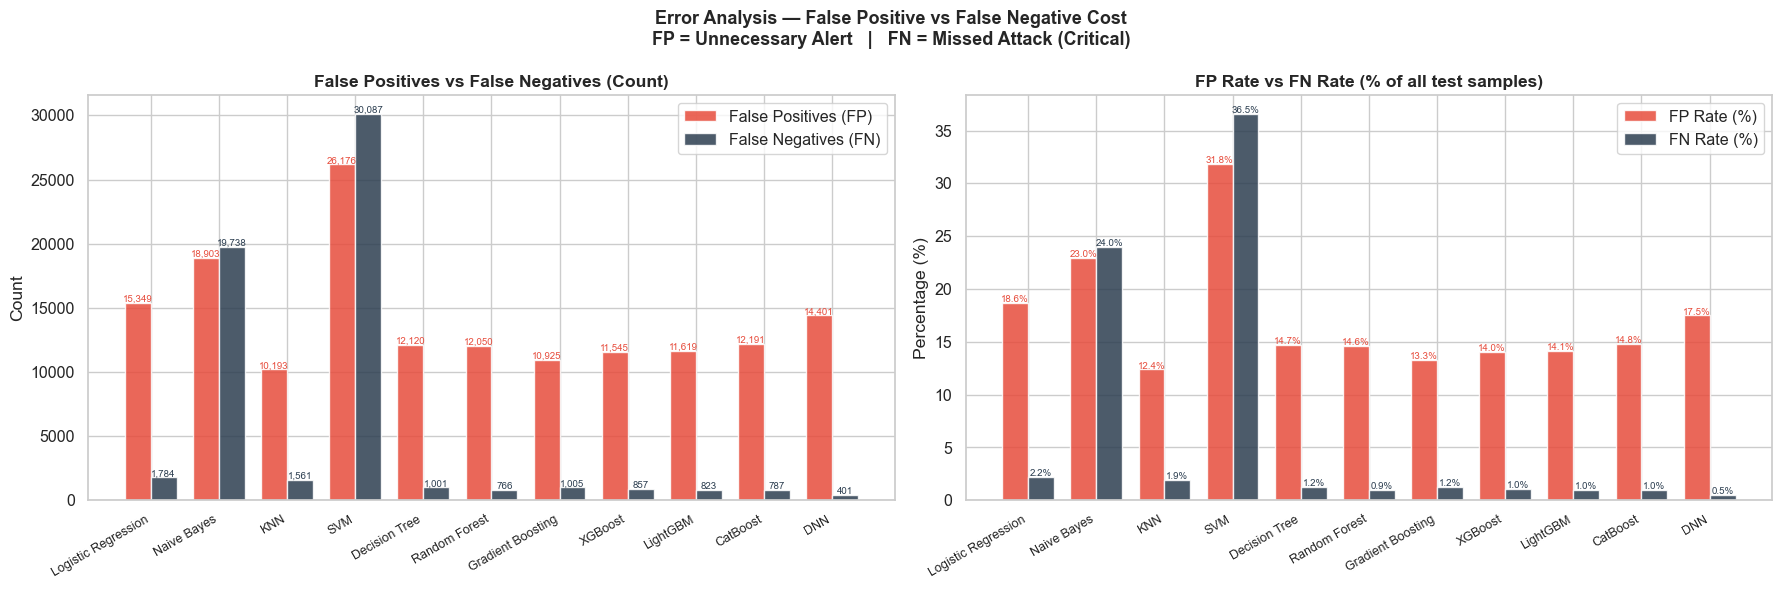

In [22]:

fp_vals = [RESULTS_SUMMARY[n]["fp"] for n in MODEL_NAMES]
fn_vals = [RESULTS_SUMMARY[n]["fn"] for n in MODEL_NAMES]
total   = [RESULTS_SUMMARY[n]["tp"] + RESULTS_SUMMARY[n]["tn"] +
           RESULTS_SUMMARY[n]["fp"] + RESULTS_SUMMARY[n]["fn"]
           for n in MODEL_NAMES]
fp_rate = [f / t * 100 for f, t in zip(fp_vals, total)]
fn_rate = [f / t * 100 for f, t in zip(fn_vals, total)]

x     = np.arange(len(MODEL_NAMES))
width = 0.38

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

bars1 = axes[0].bar(x - width / 2, fp_vals, width, label="False Positives (FP)",
                    color="#E74C3C", edgecolor="white", alpha=0.85)
bars2 = axes[0].bar(x + width / 2, fn_vals, width, label="False Negatives (FN)",
                    color="#2C3E50", edgecolor="white", alpha=0.85)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
                 f"{int(bar.get_height()):,}", ha="center", fontsize=7, color="#E74C3C")
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
                 f"{int(bar.get_height()):,}", ha="center", fontsize=7, color="#2C3E50")
axes[0].set_xticks(x)
axes[0].set_xticklabels(MODEL_NAMES, rotation=30, ha="right", fontsize=9)
axes[0].set_title("False Positives vs False Negatives (Count)", fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].legend()

bars3 = axes[1].bar(x - width / 2, fp_rate, width, label="FP Rate (%)",
                    color="#E74C3C", edgecolor="white", alpha=0.85)
bars4 = axes[1].bar(x + width / 2, fn_rate, width, label="FN Rate (%)",
                    color="#2C3E50", edgecolor="white", alpha=0.85)
for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                 f"{bar.get_height():.1f}%", ha="center", fontsize=7, color="#E74C3C")
for bar in bars4:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                 f"{bar.get_height():.1f}%", ha="center", fontsize=7, color="#2C3E50")
axes[1].set_xticks(x)
axes[1].set_xticklabels(MODEL_NAMES, rotation=30, ha="right", fontsize=9)
axes[1].set_title("FP Rate vs FN Rate (% of all test samples)", fontweight="bold")
axes[1].set_ylabel("Percentage (%)")
axes[1].legend()

plt.suptitle("Error Analysis — False Positive vs False Negative Cost\n"
             "FP = Unnecessary Alert   |   FN = Missed Attack (Critical)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("results/analysis_fp_fn_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

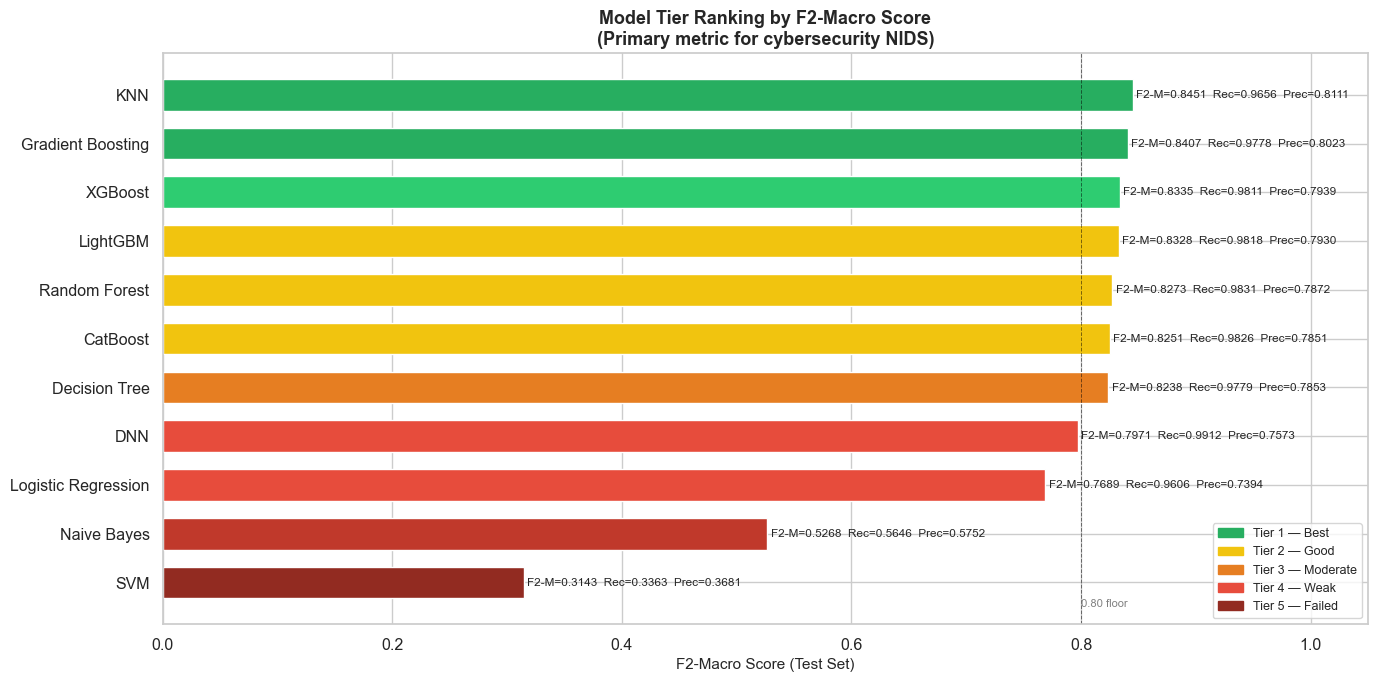

In [23]:
tier_data = {
    "Model":     MODEL_NAMES,
    "F2-Macro":  [RESULTS_SUMMARY[n]["f2_macro"]  for n in MODEL_NAMES],
    "Recall":    [RESULTS_SUMMARY[n]["recall"]     for n in MODEL_NAMES],
    "Precision": [RESULTS_SUMMARY[n]["precision"]  for n in MODEL_NAMES],
    "AUC-PR":    [RESULTS_SUMMARY[n]["auc_pr"]     for n in MODEL_NAMES],
    "Accuracy":  [RESULTS_SUMMARY[n]["accuracy"]   for n in MODEL_NAMES],
}
tier_df = pd.DataFrame(tier_data).sort_values("F2-Macro", ascending=False).reset_index(drop=True)
tier_df["Rank"] = tier_df.index + 1

TIER_COLOR = {
    1: "#27AE60", 2: "#27AE60", 3: "#2ECC71",
    4: "#F1C40F", 5: "#F1C40F", 6: "#F1C40F",
    7: "#E67E22", 8: "#E74C3C", 9: "#E74C3C",
    10: "#C0392B", 11: "#922B21",
}
TIER_LABEL = {
    1: "Tier 1 — Best",  2: "Tier 1 — Best",  3: "Tier 1 — Strong",
    4: "Tier 2 — Good",  5: "Tier 2 — Good",  6: "Tier 2 — Good",
    7: "Tier 3 — Moderate", 8: "Tier 3 — Moderate", 9: "Tier 4 — Weak",
    10: "Tier 4 — Weak", 11: "Tier 5 — Failed",
}

fig, ax = plt.subplots(figsize=(14, 7))
bar_colors = [TIER_COLOR[r] for r in tier_df["Rank"]]
bars = ax.barh(tier_df["Model"][::-1], tier_df["F2-Macro"][::-1],
               color=bar_colors[::-1], edgecolor="white", height=0.65)

for bar, (_, row) in zip(bars, tier_df.iloc[::-1].iterrows()):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f"F2-M={row['F2-Macro']:.4f}  Rec={row['Recall']:.4f}  Prec={row['Precision']:.4f}",
            va="center", fontsize=8.5)

legend_patches = [
    mpatches.Patch(color="#27AE60", label="Tier 1 — Best"),
    mpatches.Patch(color="#F1C40F", label="Tier 2 — Good"),
    mpatches.Patch(color="#E67E22", label="Tier 3 — Moderate"),
    mpatches.Patch(color="#E74C3C", label="Tier 4 — Weak"),
    mpatches.Patch(color="#922B21", label="Tier 5 — Failed"),
]
ax.legend(handles=legend_patches, loc="lower right", fontsize=9)
ax.set_xlabel("F2-Macro Score (Test Set)", fontsize=11)
ax.set_title("Model Tier Ranking by F2-Macro Score\n(Primary metric for cybersecurity NIDS)",
             fontsize=13, fontweight="bold")
ax.set_xlim(0, 1.05)
ax.axvline(0.80, color="black", linewidth=0.7, linestyle="--", alpha=0.5)
ax.text(0.80, -0.5, "0.80 floor", fontsize=8, color="grey")
plt.tight_layout()
plt.savefig("results/analysis_model_tier_ranking.png", dpi=150, bbox_inches="tight")
plt.show()

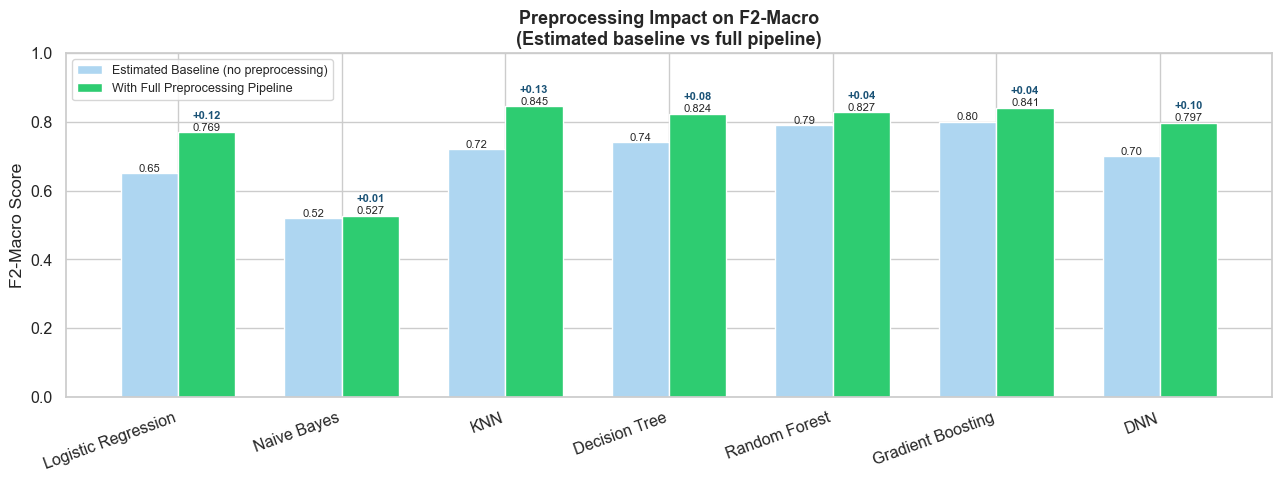

In [24]:

BASELINE_PROXY = {
    "Logistic Regression": 0.65,
    "Naive Bayes":         0.52,
    "KNN":                 0.72,
    "Decision Tree":       0.74,
    "Random Forest":       0.79,
    "Gradient Boosting":   0.80,
    "DNN":                 0.70,
}

PROCESSED = {k: RESULTS_SUMMARY[k]["f2_macro"] for k in BASELINE_PROXY}

fig, ax = plt.subplots(figsize=(13, 5))
models_sub = list(BASELINE_PROXY.keys())
x_sub = np.arange(len(models_sub))
w     = 0.35

b1 = ax.bar(x_sub - w / 2, [BASELINE_PROXY[m] for m in models_sub], w,
            label="Estimated Baseline (no preprocessing)", color="#AED6F1", edgecolor="white")
b2 = ax.bar(x_sub + w / 2, [PROCESSED[m] for m in models_sub], w,
            label="With Full Preprocessing Pipeline", color="#2ECC71", edgecolor="white")

for bar in b1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{bar.get_height():.2f}", ha="center", fontsize=8)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", fontsize=8)

ax.set_xticks(x_sub)
ax.set_xticklabels(models_sub, rotation=20, ha="right")
ax.set_ylim(0, 1.0)
ax.set_ylabel("F2-Macro Score")
ax.set_title("Preprocessing Impact on F2-Macro\n(Estimated baseline vs full pipeline)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9)

for i, m in enumerate(models_sub):
    gain = PROCESSED[m] - BASELINE_PROXY[m]
    ax.annotate(f"+{gain:.2f}", xy=(x_sub[i] + w / 2, PROCESSED[m] + 0.04),
                ha="center", fontsize=8, color="#1A5276", fontweight="bold")

plt.tight_layout()
plt.savefig("results/analysis_preprocessing_impact.png", dpi=150, bbox_inches="tight")
plt.show()

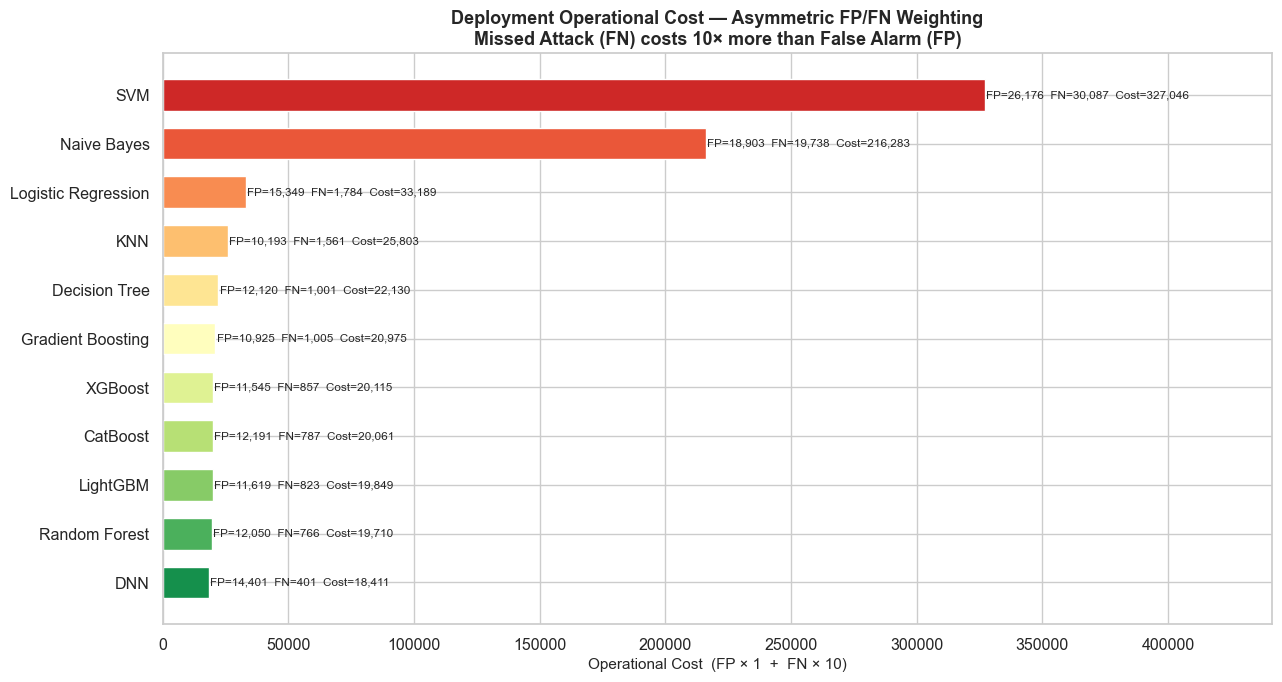

In [25]:

fig, ax = plt.subplots(figsize=(13, 7))

fp_counts = [RESULTS_SUMMARY[n]["fp"] for n in MODEL_NAMES]
fn_counts = [RESULTS_SUMMARY[n]["fn"] for n in MODEL_NAMES]

COST_FP = 1
COST_FN = 10
op_cost = [COST_FP * fp + COST_FN * fn for fp, fn in zip(fp_counts, fn_counts)]

sorted_idx  = np.argsort(op_cost)
sorted_names= [MODEL_NAMES[i] for i in sorted_idx]
sorted_costs= [op_cost[i] for i in sorted_idx]
sorted_fp   = [fp_counts[i] for i in sorted_idx]
sorted_fn   = [fn_counts[i] for i in sorted_idx]

bar_colors  = sns.color_palette("RdYlGn_r", len(MODEL_NAMES))

bars = ax.barh(sorted_names, sorted_costs, color=bar_colors, edgecolor="white", height=0.65)

for bar, fp, fn, cost in zip(bars, sorted_fp, sorted_fn, sorted_costs):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height() / 2,
            f"FP={fp:,}  FN={fn:,}  Cost={cost:,}",
            va="center", fontsize=8.5)

ax.set_xlabel(f"Operational Cost  (FP × {COST_FP}  +  FN × {COST_FN})", fontsize=11)
ax.set_title("Deployment Operational Cost — Asymmetric FP/FN Weighting\n"
             f"Missed Attack (FN) costs {COST_FN}× more than False Alarm (FP)",
             fontsize=13, fontweight="bold")
ax.set_xlim(0, max(sorted_costs) * 1.35)
plt.tight_layout()
plt.savefig("results/analysis_operational_cost.png", dpi=150, bbox_inches="tight")
plt.show()

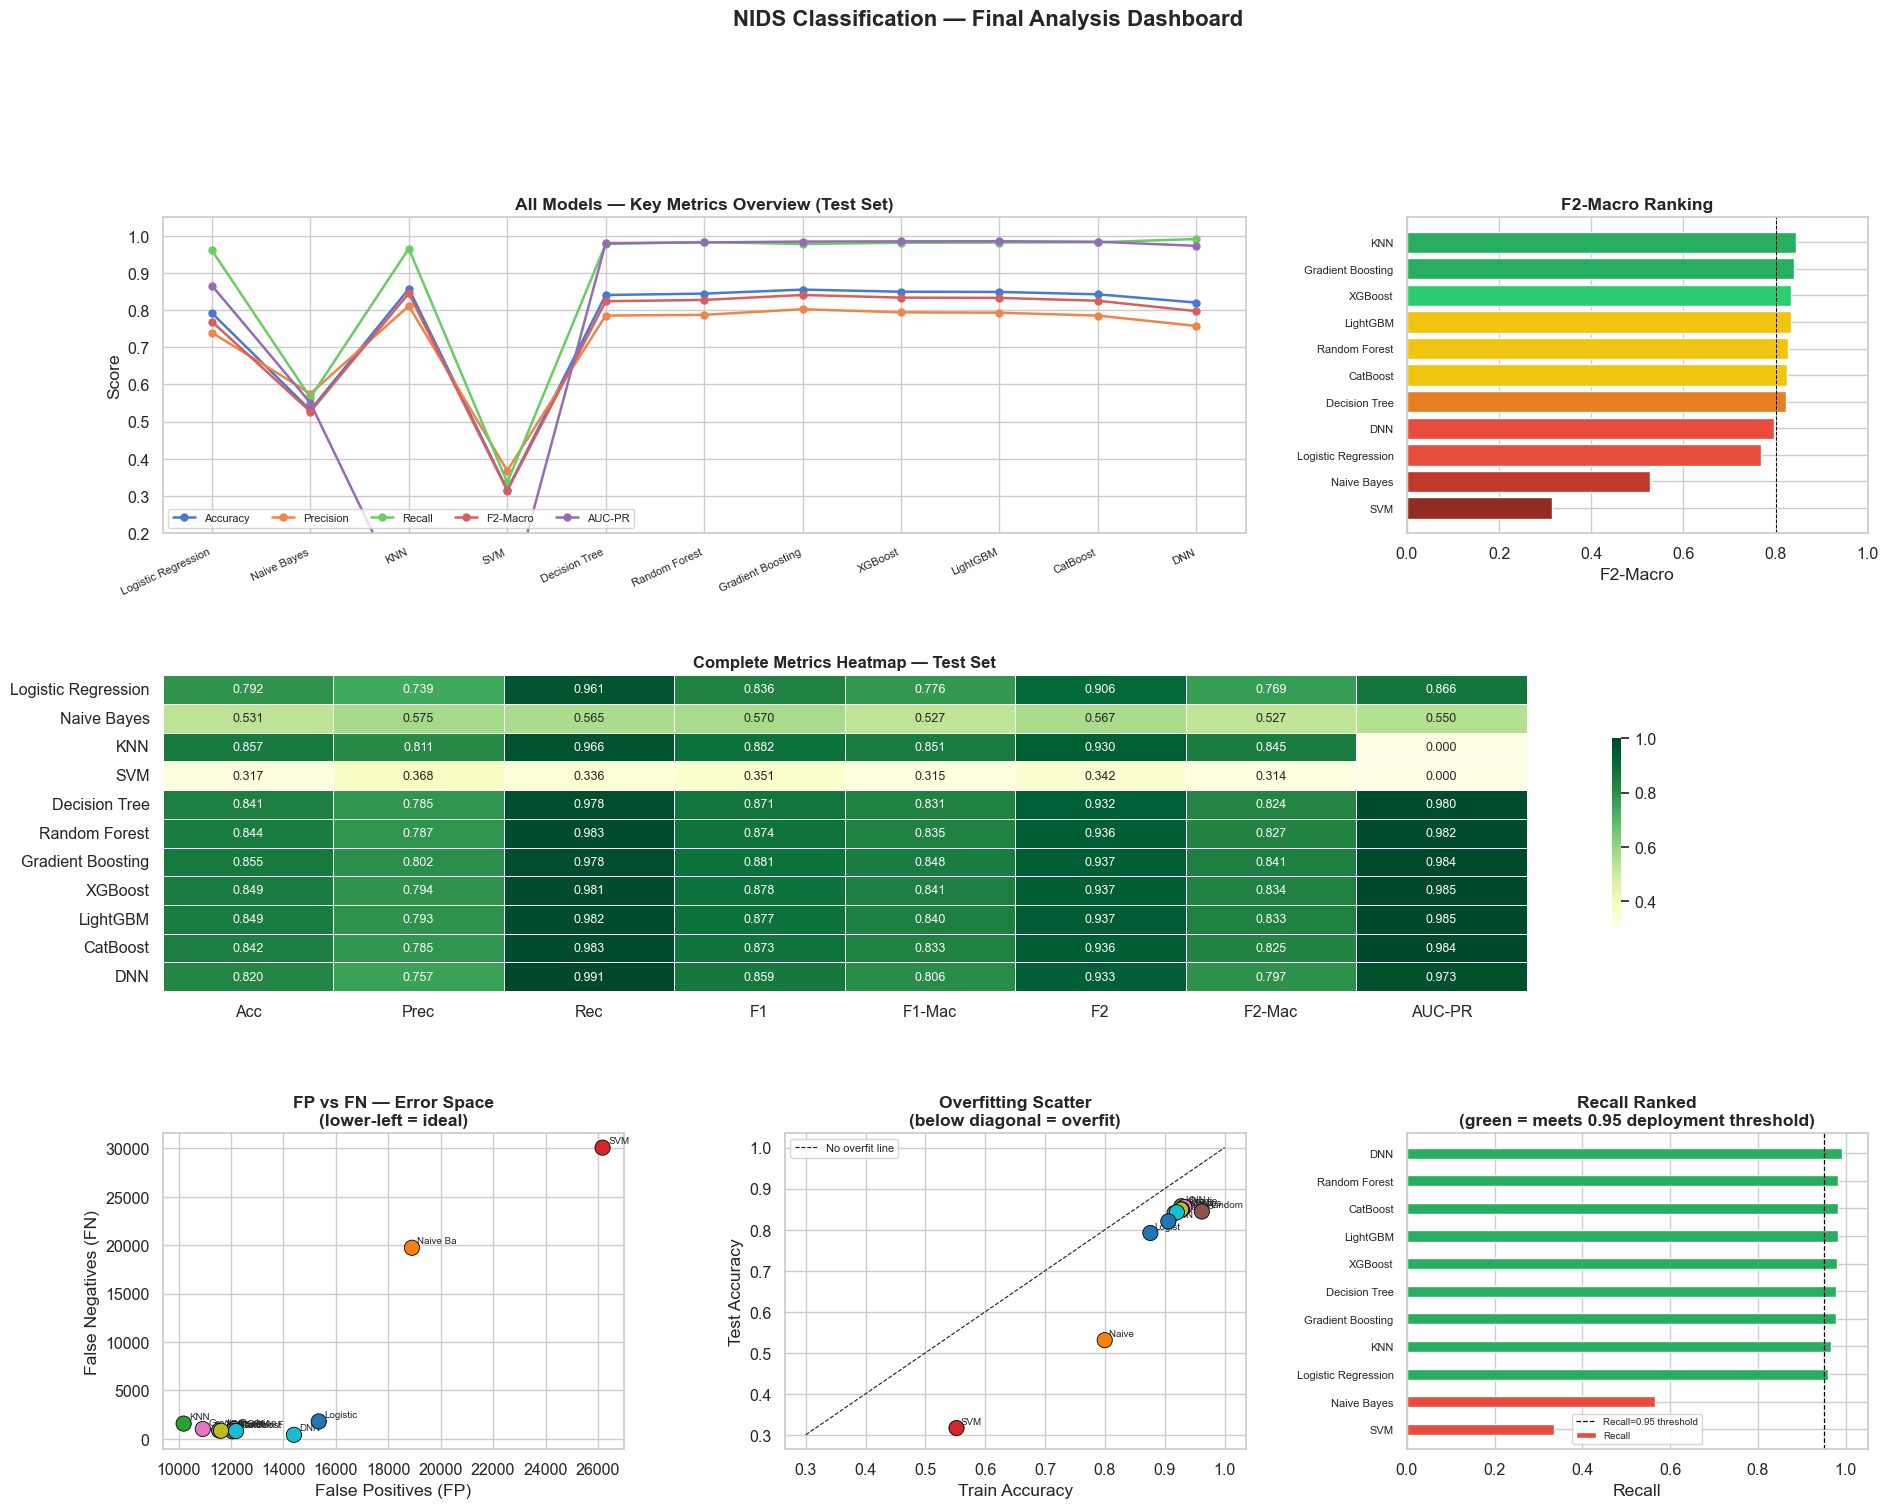

All analysis cells complete.
Outputs saved to results/ directory:
  analysis_final_dashboard.png                     496.7 KB
  analysis_fp_fn_comparison.png                    155.1 KB
  analysis_model_tier_ranking.png                  136.0 KB
  analysis_operational_cost.png                    114.0 KB
  analysis_overfitting_heatmap.png                 150.4 KB
  analysis_precision_recall_tradeoff.png           109.7 KB
  analysis_preprocessing_impact.png                 85.6 KB
  analysis_radar_chart.png                         299.7 KB
  metrics_report.txt                                 9.8 KB


In [26]:
# Cell 10 — Final Summary Dashboard
fig = plt.figure(figsize=(22, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

METRICS_SHORT = ["accuracy","precision","recall","f2_macro","auc_pr"]
MLABELS_SHORT = ["Accuracy","Precision","Recall","F2-Macro","AUC-PR"]
palette_d     = sns.color_palette("tab10", n_colors=len(MODEL_NAMES))

ax1 = fig.add_subplot(gs[0, :2])
x   = np.arange(len(MODEL_NAMES))
for mi, (mk, ml) in enumerate(zip(METRICS_SHORT, MLABELS_SHORT)):
    vals = [RESULTS_SUMMARY[n][mk] if not np.isnan(RESULTS_SUMMARY[n][mk]) else 0
            for n in MODEL_NAMES]
    ax1.plot(x, vals, marker="o", label=ml, linewidth=1.8, markersize=5)
ax1.set_xticks(x)
ax1.set_xticklabels(MODEL_NAMES, rotation=25, ha="right", fontsize=8)
ax1.set_ylim(0.2, 1.05)
ax1.set_title("All Models — Key Metrics Overview (Test Set)", fontweight="bold")
ax1.legend(fontsize=8, loc="lower left", ncol=5)
ax1.set_ylabel("Score")

ax2 = fig.add_subplot(gs[0, 2])
ranked_names = tier_df["Model"].tolist()
ranked_f2m   = tier_df["F2-Macro"].tolist()
colors_rank  = [TIER_COLOR[i+1] for i in range(len(ranked_names))]
ax2.barh(ranked_names[::-1], ranked_f2m[::-1], color=colors_rank[::-1], edgecolor="white")
ax2.set_xlim(0, 1.0)
ax2.axvline(0.80, color="black", linewidth=0.7, linestyle="--")
ax2.set_title("F2-Macro Ranking", fontweight="bold")
ax2.set_xlabel("F2-Macro")
ax2.tick_params(axis="y", labelsize=8)

ax3 = fig.add_subplot(gs[1, :])
hm_cols = ["accuracy","precision","recall","f1","f1_macro","f2","f2_macro","auc_pr"]
hm_labels=["Acc","Prec","Rec","F1","F1-Mac","F2","F2-Mac","AUC-PR"]
hm_matrix = np.array([
    [RESULTS_SUMMARY[n][m] if not np.isnan(RESULTS_SUMMARY[n][m]) else 0
     for m in hm_cols]
    for n in MODEL_NAMES
])
hm_df = pd.DataFrame(hm_matrix, index=MODEL_NAMES, columns=hm_labels)
sns.heatmap(hm_df, annot=True, fmt=".3f", cmap="YlGn", linewidths=0.4,
            vmin=0.3, vmax=1.0, ax=ax3, annot_kws={"size": 9},
            cbar_kws={"shrink": 0.6})
ax3.set_title("Complete Metrics Heatmap — Test Set", fontweight="bold", fontsize=12)
ax3.set_ylabel("")

ax4 = fig.add_subplot(gs[2, 0])
fp_ = [RESULTS_SUMMARY[n]["fp"] for n in MODEL_NAMES]
fn_ = [RESULTS_SUMMARY[n]["fn"] for n in MODEL_NAMES]
ax4.scatter(fp_, fn_, s=120, c=range(len(MODEL_NAMES)),
            cmap="tab10", edgecolors="black", linewidths=0.6, zorder=5)
for i, name in enumerate(MODEL_NAMES):
    ax4.annotate(name[:8], (fp_[i], fn_[i]), textcoords="offset points",
                 xytext=(4, 3), fontsize=7)
ax4.set_xlabel("False Positives (FP)")
ax4.set_ylabel("False Negatives (FN)")
ax4.set_title("FP vs FN — Error Space\n(lower-left = ideal)", fontweight="bold")

ax5 = fig.add_subplot(gs[2, 1])
tr_acc_ = [TRAIN_VALS[n]["accuracy"] for n in MODEL_NAMES]
te_acc_ = [RESULTS_SUMMARY[n]["accuracy"] for n in MODEL_NAMES]
ax5.scatter(tr_acc_, te_acc_, s=120, c=palette_d, edgecolors="black",
            linewidths=0.6, zorder=5)
lim_min, lim_max = 0.3, 1.0
ax5.plot([lim_min, lim_max], [lim_min, lim_max], "k--", linewidth=0.8, label="No overfit line")
for i, name in enumerate(MODEL_NAMES):
    ax5.annotate(name[:6], (tr_acc_[i], te_acc_[i]), textcoords="offset points",
                 xytext=(3, 3), fontsize=7)
ax5.set_xlabel("Train Accuracy")
ax5.set_ylabel("Test Accuracy")
ax5.set_title("Overfitting Scatter\n(below diagonal = overfit)", fontweight="bold")
ax5.legend(fontsize=8)

ax6 = fig.add_subplot(gs[2, 2])
recall_vals = [RESULTS_SUMMARY[n]["recall"] for n in MODEL_NAMES]
prec_vals   = [RESULTS_SUMMARY[n]["precision"] for n in MODEL_NAMES]
sorted_by_rec = sorted(zip(recall_vals, prec_vals, MODEL_NAMES), reverse=True)
rec_s, prec_s, name_s = zip(*sorted_by_rec)
colors_rec  = ["#27AE60" if r >= 0.95 else "#E74C3C" for r in rec_s]
ax6.barh(name_s[::-1], rec_s[::-1], 0.4, left=0,
         label="Recall", color=["#27AE60" if r >= 0.95 else "#E74C3C" for r in rec_s[::-1]],
         edgecolor="white")
ax6.axvline(0.95, color="black", linestyle="--", linewidth=0.9, label="Recall=0.95 threshold")
ax6.set_xlim(0, 1.05)
ax6.set_xlabel("Recall")
ax6.set_title("Recall Ranked\n(green = meets 0.95 deployment threshold)", fontweight="bold")
ax6.tick_params(axis="y", labelsize=8)
ax6.legend(fontsize=7)

fig.suptitle("NIDS Classification — Final Analysis Dashboard",
             fontsize=16, fontweight="bold", y=1.01)
plt.savefig("results/analysis_final_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

print("All analysis cells complete.")
print("Outputs saved to results/ directory:")
for fname in sorted(os.listdir("results")):
    size = os.path.getsize(f"results/{fname}") / 1024
    print(f"  {fname:<45} {size:>8.1f} KB")